In [1]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis
from scipy.spatial import distance
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import torch
import torch.nn as nn
import torch.optim as optim
import random
import os

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)

In [5]:
train_data = pd.read_csv('train_data.txt', sep='\t')

In [6]:
train_data

,faultNumber,simulationRun,sample,a_feed_stream,d_feed_stream,e_feed_stream,a_and_c_feed_stream,recycle_flow,reactor_feed_rate,reactor_pressure,...,a_feed_flow_valve,a_and_c_feed_flow_valve,compressor_recycle_valve,purge_valve,separator_pot_liquid_flow_valve,stripper_liquid_product_flow_valve,stripper_steam_valve,reactor_cooling_water_flow_valve,condenser_cooling_water_flow_valve,fault_label
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,0
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,0
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,0
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,0
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5249995,20.0,500.0,496,0.23419,3655.3,4461.7,9.3448,27.008,42.481,2703.0,...,23.350,61.061,20.719,40.999,38.653,47.386,47.528,40.212,17.659,1
5249996,20.0,500.0,497,0.26704,3647.4,4540.2,9.3546,27.034,42.671,2704.7,...,26.362,60.020,20.263,41.579,33.624,47.536,47.647,41.199,18.741,1
5249997,20.0,500.0,498,0.26543,3630.3,4571.6,9.4089,27.129,42.470,2705.1,...,26.521,59.824,20.189,41.505,40.967,52.437,47.802,41.302,23.199,1
5249998,20.0,500.0,499,0.27671,3655.7,4498.9,9.3781,27.353,42.281,2705.8,...,26.781,62.818,20.453,40.208,40.957,47.628,48.086,40.510,15.932,1


In [7]:
# Create the episode_id and sort to ensure chronological order
train_data['episode_id'] = train_data['faultNumber'].astype(int).astype(str) + '_' + train_data['simulationRun'].astype(int).astype(str)
train_data.sort_values(by=['episode_id', 'sample'], inplace=True)
train_data.reset_index(drop=True, inplace=True)

In [8]:
train_data

,faultNumber,simulationRun,sample,a_feed_stream,d_feed_stream,e_feed_stream,a_and_c_feed_stream,recycle_flow,reactor_feed_rate,reactor_pressure,...,a_and_c_feed_flow_valve,compressor_recycle_valve,purge_valve,separator_pot_liquid_flow_valve,stripper_liquid_product_flow_valve,stripper_steam_valve,reactor_cooling_water_flow_valve,condenser_cooling_water_flow_valve,fault_label,episode_id
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,0,0_1
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,0,0_1
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,0,0_1
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,0,0_1
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,0,0_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5249995,9.0,99.0,496,0.25147,3668.5,4489.8,9.4907,27.193,42.297,2710.2,...,59.802,22.513,40.020,35.508,47.911,43.069,40.539,18.430,1,9_99
5249996,9.0,99.0,497,0.24029,3691.6,4508.6,9.2858,27.045,42.281,2709.1,...,59.213,22.318,38.852,38.097,44.495,42.832,41.806,18.825,1,9_99
5249997,9.0,99.0,498,0.24069,3684.0,4481.9,9.3167,27.098,42.521,2702.9,...,63.121,21.971,39.280,39.266,47.102,42.611,40.998,18.444,1,9_99
5249998,9.0,99.0,499,0.25026,3713.3,4512.6,9.3413,27.080,42.498,2700.9,...,59.045,22.074,39.910,38.217,46.705,42.493,41.966,18.712,1,9_99


In [9]:
# Episode construction
train_data['episode_id'] = (
    train_data['faultNumber'].astype(int).astype(str) + '_' +
    train_data['simulationRun'].astype(int).astype(str)
)
train_data.sort_values(by=['episode_id', 'sample'], inplace=True)
train_data.reset_index(drop=True, inplace=True)

# Check for missing values
print(train_data.isnull().sum().sort_values(ascending=False))

faultNumber                            0
composition_of_e_rxtr_feed             0
composition_of_a_purge                 0
Composition_of_b_purge                 0
composition_of_c_purge                 0
Composition_of_d_purge                 0
composition_of_e_purge                 0
Composition_of_f_purge                 0
composition_of_g_purge                 0
composition_of_h_purge                 0
composition_of_d_product               0
composition_of_e_product               0
composition_of_f_product               0
composition_of_g_product               0
composition_of_h_product               0
d_feed_flow_valve                      0
e_feed_flow_valve                      0
a_feed_flow_valve                      0
a_and_c_feed_flow_valve                0
compressor_recycle_valve               0
purge_valve                            0
separator_pot_liquid_flow_valve        0
stripper_liquid_product_flow_valve     0
stripper_steam_valve                   0
reactor_cooling_

In [10]:
# Define the non-sensor and sensor columns
non_sensor_cols = ['fault_label','faultNumber', 'simulationRun', 'sample', 'episode_id']
sensor_cols = [col for col in train_data.columns if col not in non_sensor_cols]
print("\nNumber of sensor columns:", len(sensor_cols))


Number of sensor columns: 52



Fault distribution (counts):
faultNumber
0.0     250000
1.0     250000
2.0     250000
3.0     250000
4.0     250000
5.0     250000
6.0     250000
7.0     250000
8.0     250000
9.0     250000
10.0    250000
11.0    250000
12.0    250000
13.0    250000
14.0    250000
15.0    250000
16.0    250000
17.0    250000
18.0    250000
19.0    250000
20.0    250000
Name: count, dtype: int64


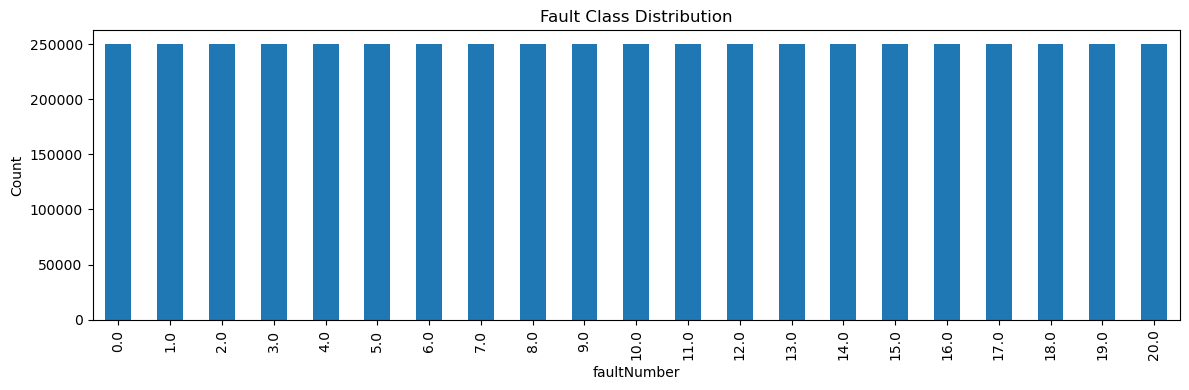

In [11]:
# Class distribution + run/time structure
print("\nFault distribution (counts):")
fault_counts = train_data['faultNumber'].value_counts().sort_index()
print(fault_counts)

plt.figure(figsize=(12, 4))
fault_counts.plot(kind='bar')
plt.title("Fault Class Distribution")
plt.xlabel("faultNumber")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [12]:
# Simulation length / structure
print("\nPer-simulation sample range:")
sample_range = train_data.groupby('episode_id')['sample'].agg(['min', 'max', 'count']).sort_values('count', ascending=False)
print(sample_range.head(10))

# Check if each episode_id contain exactly one faultNumber?
faults_per_episode = train_data.groupby('episode_id')['faultNumber'].nunique()
print("\nFaultNumber unique values per episode_id (should be 1 for each):")
print(faults_per_episode.value_counts().sort_index())


Per-simulation sample range:
            min  max  count
episode_id                 
0_1           1  500    500
2_94          1  500    500
2_96          1  500    500
2_97          1  500    500
2_98          1  500    500
2_99          1  500    500
3_1           1  500    500
3_10          1  500    500
3_100         1  500    500
3_101         1  500    500

FaultNumber unique values per episode_id (should be 1 for each):
faultNumber
1    10500
Name: count, dtype: int64


In [13]:
fault_means = train_data.groupby('faultNumber')[sensor_cols].mean()
fault_stds = train_data.groupby('faultNumber')[sensor_cols].std()

print("\nFault-level mean table shape:", fault_means.shape)
print("Fault-level std table shape:", fault_stds.shape)


Fault-level mean table shape: (21, 52)
Fault-level std table shape: (21, 52)


In [14]:
fault_means

,a_feed_stream,d_feed_stream,e_feed_stream,a_and_c_feed_stream,recycle_flow,reactor_feed_rate,reactor_pressure,reactor_level,reactor_temp,purge_rate,...,e_feed_flow_valve,a_feed_flow_valve,a_and_c_feed_flow_valve,compressor_recycle_valve,purge_valve,separator_pot_liquid_flow_valve,stripper_liquid_product_flow_valve,stripper_steam_valve,reactor_cooling_water_flow_valve,condenser_cooling_water_flow_valve
faultNumber,,,,,,,,,,,,,,,,,,,,,
0.0,0.250482,3663.785706,4508.819790,9.347101,26.902196,42.337598,2705.037865,75.000086,120.400022,0.337055,...,53.973668,24.639472,61.298501,22.216644,40.055456,38.098898,46.534295,47.958591,41.104304,18.118706
1.0,0.737984,3657.578606,4484.690838,8.817826,26.902225,42.290595,2711.468287,75.114673,120.399974,0.318768,...,53.684823,72.594558,57.827091,22.093039,37.962937,38.075384,46.398195,63.776696,40.984424,18.189834
2.0,0.279712,3693.648346,4643.706991,9.601209,26.902205,42.644974,2705.018107,74.943853,120.400089,0.666388,...,55.588382,27.514793,62.965138,21.673739,79.160012,37.661596,46.496409,29.572280,41.430072,17.128814
3.0,0.250483,3663.780610,4508.796916,9.347076,26.902200,42.337684,2705.036782,75.000080,120.400033,0.337144,...,53.973393,24.639527,61.298340,22.216208,40.066008,38.098910,46.534330,47.957073,41.178004,18.118536
4.0,0.250482,3663.784468,4508.821648,9.347101,26.902193,42.337589,2705.038461,75.000086,120.399980,0.337055,...,53.973691,24.639481,61.298498,22.216688,40.055424,38.098876,46.534293,47.958179,44.720888,18.118717
5.0,0.250490,3660.736824,4500.069622,9.333698,26.902177,42.313984,2703.915134,75.000577,120.400009,0.336499,...,53.868921,24.640232,61.210615,22.208942,40.030254,38.031094,46.470594,47.310315,41.040169,20.703907
6.0,0.010016,3622.753982,4298.449003,9.584099,26.884559,42.293341,2947.582386,74.215094,120.402258,0.233418,...,48.317360,95.536933,78.572110,28.564416,13.541373,38.827490,45.687908,90.341206,49.947978,27.794490
7.0,0.251259,3662.716052,4506.859570,9.342884,26.902109,42.334465,2705.615993,74.759221,120.400025,0.336727,...,53.950204,24.715938,75.976376,22.265068,40.024778,38.105143,46.516770,51.126329,41.093380,18.144273
8.0,0.256920,3662.992385,4507.509935,9.337532,26.902238,42.335200,2702.900593,74.998300,120.400019,0.335861,...,53.957987,25.272787,61.235751,22.685416,39.712121,38.102325,46.523242,50.983203,41.128512,18.086895


In [15]:
fault_stds

,a_feed_stream,d_feed_stream,e_feed_stream,a_and_c_feed_stream,recycle_flow,reactor_feed_rate,reactor_pressure,reactor_level,reactor_temp,purge_rate,...,e_feed_flow_valve,a_feed_flow_valve,a_and_c_feed_flow_valve,compressor_recycle_valve,purge_valve,separator_pot_liquid_flow_valve,stripper_liquid_product_flow_valve,stripper_steam_valve,reactor_cooling_water_flow_valve,condenser_cooling_water_flow_valve
faultNumber,,,,,,,,,,,,,,,,,,,,,
0.0,0.030873,34.006357,39.215420,0.085721,0.211485,0.218513,7.525596,0.542026,0.019109,0.012529,...,0.469663,3.037743,1.243805,0.530156,1.526751,2.965266,2.351304,2.716520,0.540817,1.463678
1.0,0.152406,37.374090,79.192332,0.272906,0.211537,0.253669,33.758573,1.185646,0.020091,0.023399,...,0.948278,14.991761,2.104977,1.861262,2.874303,2.980568,2.366131,14.394252,0.797361,1.520108
2.0,0.031876,36.021978,66.288484,0.117328,0.211589,0.243578,20.943038,0.562180,0.019200,0.110868,...,0.795319,3.135895,1.351402,0.905906,13.238362,2.971682,2.352373,9.257951,0.564874,1.534045
3.0,0.030873,34.007649,39.217413,0.085736,0.211485,0.218527,7.530042,0.542071,0.019105,0.012534,...,0.469695,3.037680,1.243842,0.530267,1.527317,2.965268,2.351309,2.715342,0.540704,1.463680
4.0,0.030874,34.005240,39.216766,0.085726,0.211483,0.218517,7.526031,0.542046,0.019782,0.012530,...,0.469670,3.037794,1.243818,0.530318,1.526808,2.965248,2.351288,2.717760,0.904546,1.463657
5.0,0.060345,36.288961,66.289443,0.170081,0.211472,0.243030,21.925120,0.851120,0.019761,0.018362,...,0.794102,5.936197,1.573728,1.454488,2.398318,2.973366,2.362656,8.536376,0.701971,1.594437
6.0,0.049296,34.810633,96.609315,0.146165,0.125348,0.156904,97.285629,0.685304,0.020289,0.039310,...,4.297356,16.220765,14.656560,37.538824,14.327035,1.621210,1.307600,19.298454,37.031902,17.758565
7.0,0.104842,42.394200,115.619214,0.323905,0.211578,0.310841,43.164209,1.802333,0.022678,0.027027,...,1.385005,10.313802,4.139000,2.928010,3.693135,2.994905,2.380767,16.123939,1.116992,1.502180
8.0,0.181802,42.104488,112.656971,0.386513,0.211636,0.316692,51.623413,1.663271,0.022993,0.076257,...,1.348110,17.883632,2.766322,2.982308,8.982462,3.001031,2.406622,18.528388,1.090388,1.570318


In [16]:
# Detect unobservable faults
normal_std = fault_stds.loc[0]
std_differences = (fault_stds - normal_std).abs().sum(axis=1)
print(std_differences.sort_values())

faultNumber
0.0       0.000000
3.0       0.024119
4.0       0.383080
9.0       0.671972
15.0      1.158863
19.0      2.539459
11.0      3.387017
14.0      8.375956
17.0      9.976643
20.0     21.633582
16.0     23.724758
10.0     40.781888
5.0     113.245942
2.0     123.402102
1.0     199.521206
7.0     282.694613
8.0     341.706670
12.0    518.098121
13.0    542.811900
6.0     593.314363
18.0    978.880026
dtype: float64


In [17]:
# Calculate stability and kurtosis
train_normal = train_data[train_data['faultNumber'] == 0]
stats = pd.DataFrame(index=sensor_cols)
stats['mean'] = train_normal[sensor_cols].mean()
stats['std'] = train_normal[sensor_cols].std()

In [18]:
stats['stability_score'] = (stats['mean'] / stats['std'].replace(0, np.nan)).abs()
stats['kurtosis'] = train_normal[sensor_cols].apply(lambda x: kurtosis(x, nan_policy='omit'))

In [19]:
# Calculate drift per episode (end - start)
def calculate_drift_per_episode(episode_train):
    window = max(1, int(len(episode_train) * 0.05)) 
    start_mean = episode_train[sensor_cols].head(window).mean()
    end_mean = episode_train[sensor_cols].tail(window).mean()
    return (end_mean - start_mean).abs()

In [20]:
episode_drifts = train_normal.groupby('episode_id').apply(calculate_drift_per_episode)
stats['avg_drift_magnitude'] = episode_drifts.mean()

C:\Users\J\AppData\Local\Temp\ipykernel_19796\308833631.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  episode_drifts = train_normal.groupby('episode_id').apply(calculate_drift_per_episode)


In [21]:
print("\nBaseline Sensor Statistics (Normal)")
print(stats.sort_values(by='stability_score', ascending=False).head(10))


Baseline Sensor Statistics (Normal)
                                            mean       std  stability_score  \
reactor_temp                          120.400022  0.019109      6300.860176   
reactor_cooling_water_outlet_temp      94.600230  0.131289       720.550044   
stripper_pressure                    3102.225506  6.519595       475.830985   
reactor_pressure                     2705.037865  7.525596       359.445012   
separator_temp                         80.106815  0.238584       335.759759   
separator_pressure                   2633.769686  7.865848       334.836082   
condenser_cooling_water_outlet_temp    77.294780  0.260763       296.417609   
compressor_work                       341.431467  1.649828       206.949679   
reactor_feed_rate                      42.337598  0.218513       193.752801   
stripper_temperature                   65.801011  0.425521       154.636297   

                                     kurtosis  avg_drift_magnitude  
reactor_temp            

In [22]:
drift_ranking = stats.sort_values(by='avg_drift_magnitude', ascending=False)

print("Top 10 Sensors with the highest drift ")
print(drift_ranking[['avg_drift_magnitude', 'stability_score']].head(10))

print("\nTop 10 Sensors with the lowest drift (Most Stable)")
print(drift_ranking[['avg_drift_magnitude', 'stability_score']].tail(10))

Top 10 Sensors with the highest drift 
                                 avg_drift_magnitude  stability_score
e_feed_stream                              15.448560       114.975684
d_feed_stream                              10.220424       107.738258
stripper_steam_flow                         8.921995        22.404749
separator_pressure                          5.809248       334.836082
reactor_pressure                            5.578400       359.445012
stripper_pressure                           4.700928       475.830985
stripper_steam_valve                        2.337859        17.654423
a_feed_flow_valve                           1.499203         8.111113
compressor_work                             1.300856       206.949679
separator_pot_liquid_flow_valve             0.687984        12.848391

Top 10 Sensors with the lowest drift (Most Stable)
                            avg_drift_magnitude  stability_score
composition_of_d_rxtr_feed             0.023053        64.040745
compositi

In [23]:
kurtosis_ranking = stats.sort_values(by='kurtosis', ascending=False)

print("Top 10 Sensors with the highest kurtosis")
print(kurtosis_ranking[['kurtosis', 'std']].head(10))

Top 10 Sensors with the highest kurtosis
                          kurtosis        std
stripper_steam_valve      0.365671   2.716520
stripper_steam_flow       0.362632  10.362103
stripper_temperature      0.299712   0.425521
composition_of_e_product  0.185064   0.018453
compressor_work           0.111967   1.649828
stripper_pressure         0.111090   6.519595
reactor_pressure          0.097461   7.525596
separator_pressure        0.092480   7.865848
compressor_recycle_valve  0.061026   0.530156
composition_of_c_purge    0.056654   0.385832


In [24]:
# Multicollinearity quantification
corr_abs = train_data[sensor_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (upper > 0.90).sum().sum()

print(f"\nNumber of sensor pairs with |corr| > 0.90: {int(high_corr_pairs)}")

top_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 correlated sensor pairs:")
print(top_pairs)



Number of sensor pairs with |corr| > 0.90: 22

Top 10 correlated sensor pairs:
separator_level             separator_pot_liquid_flow_valve       1.000000
stripper_level              stripper_liquid_product_flow_valve    1.000000
reactor_pressure            separator_pressure                    0.997393
composition_of_c_rxtr_feed  composition_of_c_purge                0.985935
composition_of_a_rxtr_feed  composition_of_a_purge                0.984290
reactor_pressure            stripper_pressure                     0.983932
separator_pressure          stripper_pressure                     0.974476
composition_of_f_rxtr_feed  Composition_of_f_purge                0.963749
separator_temp              composition_of_g_purge                0.948192
reactor_pressure            composition_of_g_purge                0.943216
dtype: float64


In [25]:
# Correlation shift score
corr_normal = train_data[train_data['faultNumber'] == 0][sensor_cols].corr()
correlation_shifts = {}
faults = [f for f in train_data['faultNumber'].unique() if f != 0]
for fault in faults:
    # Calculate correlation for the specific fault
    corr_fault = train_data[train_data['faultNumber'] == fault][sensor_cols].corr()
    # Absolute difference from normal
    corr_diff = (corr_normal - corr_fault).abs()
    # Sum all the differences to get a single score for this fault
    shift_score = corr_diff.sum().sum() / 2 
    correlation_shifts[fault] = shift_score

In [26]:
# Rank the faults by how much they changed the correlations
shift_train = pd.DataFrame(list(correlation_shifts.items()), columns=['Fault', 'Shift_Score'])
shift_train = shift_train.sort_values(by='Shift_Score', ascending=False).reset_index(drop=True)

print("Faults Ranked by Correlation Shift")
print(shift_train)

Faults Ranked by Correlation Shift
    Fault  Shift_Score
0    18.0   592.536924
1     6.0   453.656802
2    12.0   372.927713
3     7.0   331.652989
4    13.0   256.392904
5     8.0   234.042857
6     2.0   231.634413
7     1.0   216.829117
8     5.0   186.584066
9    10.0    74.477020
10   20.0    51.265877
11   16.0    38.403183
12   17.0    33.733201
13   19.0    14.841600
14   14.0    13.008852
15   11.0    11.321367
16   15.0     4.116855
17    9.0     2.629550
18    4.0     2.081280
19    3.0     0.155671


The top 20 most disrupted sensors
['composition_of_b_rxtr_feed', 'Composition_of_d_purge', 'Composition_of_b_purge', 'composition_of_f_rxtr_feed', 'd_feed_stream', 'purge_valve', 'composition_of_a_rxtr_feed', 'composition_of_a_purge', 'composition_of_e_rxtr_feed', 'composition_of_h_purge', 'Composition_of_f_purge', 'composition_of_d_rxtr_feed', 'a_and_c_feed_flow_valve', 'reactor_cooling_water_outlet_temp', 'composition_of_g_purge', 'stripper_steam_flow', 'composition_of_e_purge', 'a_feed_flow_valve', 'a_feed_stream', 'd_feed_flow_valve']


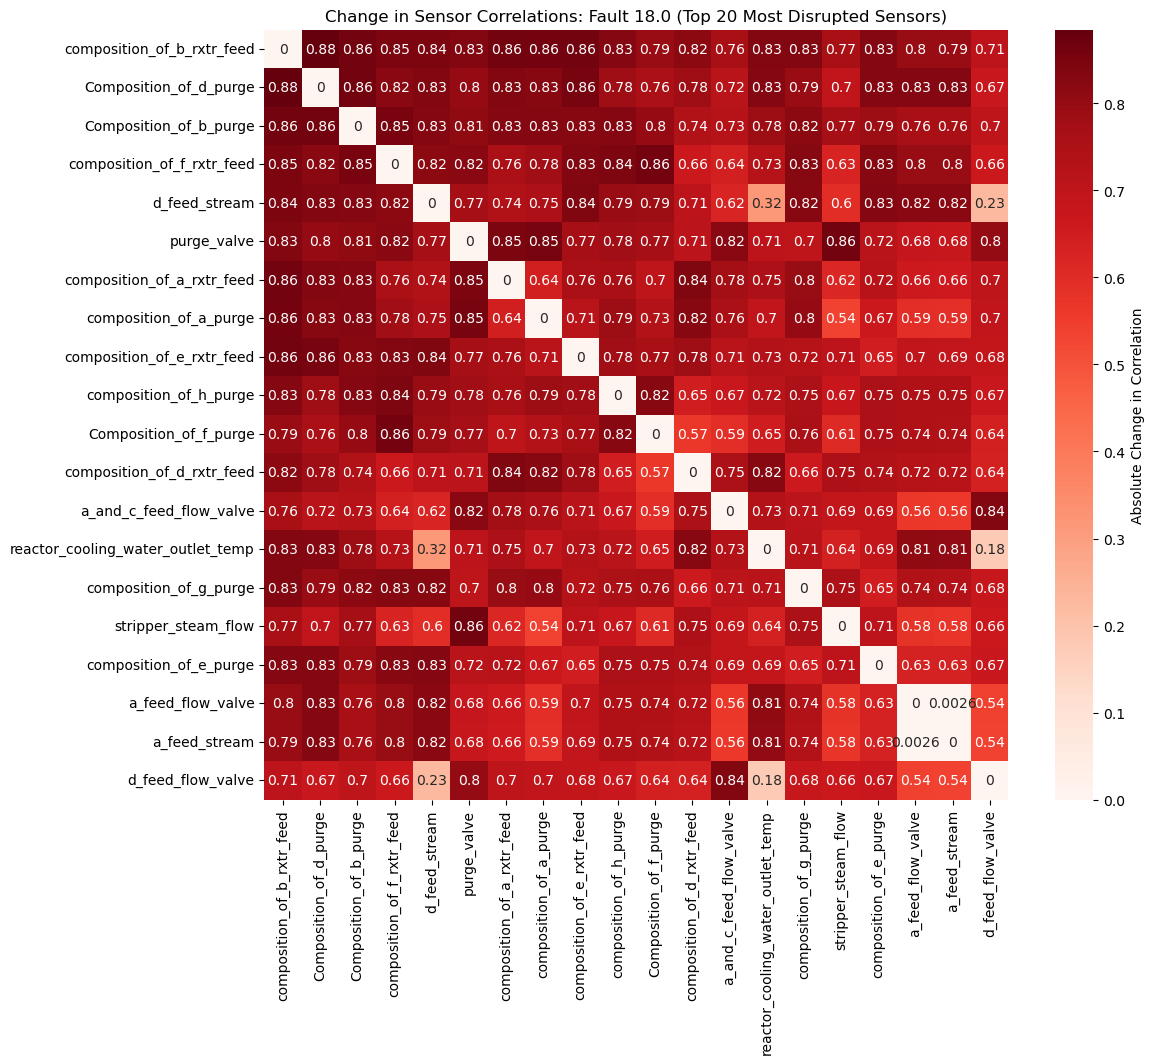

In [27]:
top_fault = shift_train.iloc[0]['Fault']
corr_top_fault = train_data[train_data['faultNumber'] == top_fault][sensor_cols].corr()
corr_diff_top = (corr_normal - corr_top_fault).abs()
# Calculate how much each sensor's correlations changed overall
sensor_change_scores = corr_diff_top.sum()
# Sort the sensors to find the ones that experienced the most broken relationships
most_changed_sensors = sensor_change_scores.sort_values(ascending=False)
# Top 20 most affected sensors 
best_subset_cols = most_changed_sensors.head(20).index.tolist()

print("The top 20 most disrupted sensors")
print(best_subset_cols)

# Heatmap 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_diff_top.loc[best_subset_cols, best_subset_cols], 
            cmap='Reds', 
            annot=True, 
            cbar_kws={'label': 'Absolute Change in Correlation'})

plt.title(f'Change in Sensor Correlations: Fault {top_fault} (Top 20 Most Disrupted Sensors)')
plt.show()

The sensor most affected by Fault 18.0 is compressor_recycle_valve


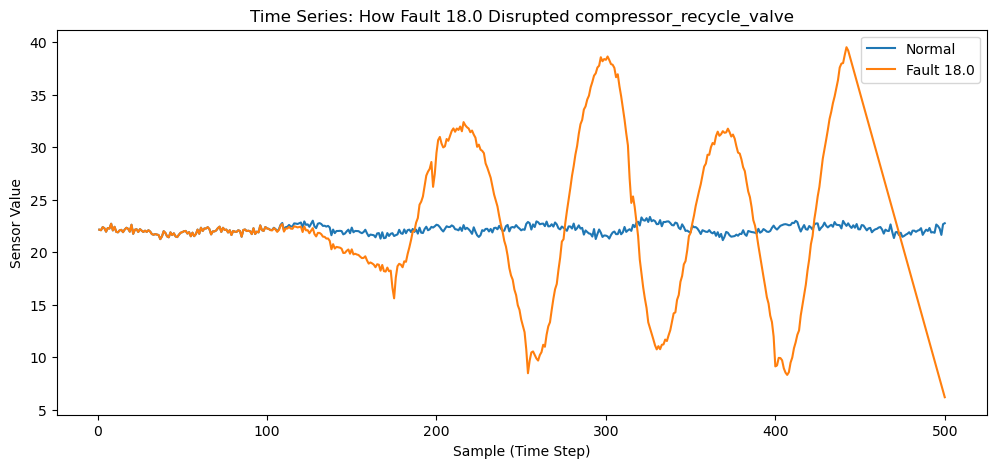

In [28]:
normal_means = train_data[train_data['faultNumber'] == 0][sensor_cols].mean()
fault_means = train_data[train_data['faultNumber'] == top_fault][sensor_cols].mean()

# Calculate the percentage shift for every sensor
mean_shifts = ((fault_means - normal_means) / normal_means).abs()

top_sensor = mean_shifts.idxmax()
print(f"The sensor most affected by Fault {top_fault} is {top_sensor}")

normal_episode = train_data[(train_data['faultNumber'] == 0) & (train_data['simulationRun'] == 1)]
faulty_episode = train_data[(train_data['faultNumber'] == top_fault) & (train_data['simulationRun'] == 1)]

plt.figure(figsize=(12, 5))
plt.plot(normal_episode['sample'], normal_episode[top_sensor], label='Normal')
plt.plot(faulty_episode['sample'], faulty_episode[top_sensor], label=f'Fault {top_fault}')
plt.title(f'Time Series: How Fault {top_fault} Disrupted {top_sensor}')
plt.xlabel('Sample (Time Step)')
plt.ylabel('Sensor Value')
plt.legend()
plt.show()


# components to reach >=95% explained variance: 25


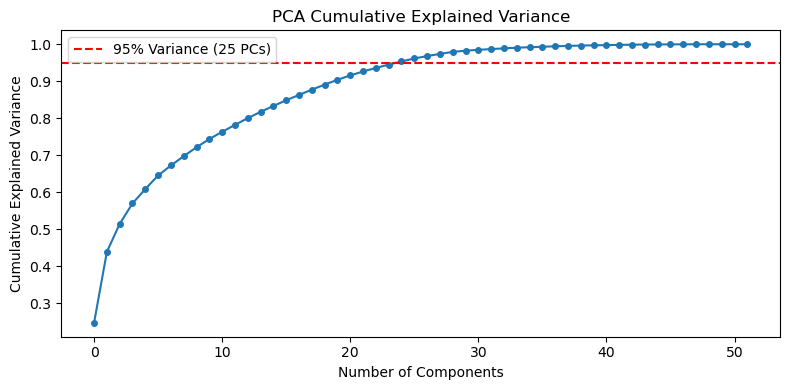

The fault most easily separated from normal data is Fault 6


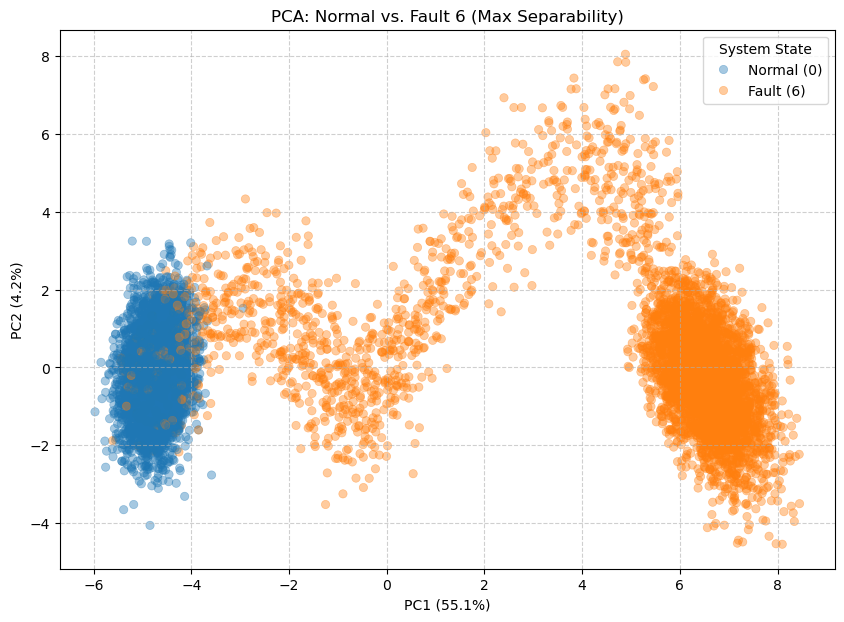

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_data[sensor_cols])

pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Number of components for 95% variance
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"\n# components to reach >=95% explained variance: {n95}")

plt.figure(figsize=(8, 4))
plt.plot(cum_var, marker='o', markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label=f'95% Variance ({n95} PCs)')
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

scaled_train = pd.DataFrame(X_scaled, columns=sensor_cols)
scaled_train['faultNumber'] = train_data['faultNumber'].astype(int).values

# Calculate centroids per fault
scaled_means = scaled_train.groupby('faultNumber').mean()

if 0 not in scaled_means.index:
    raise ValueError("Fault '0' (Normal) not found in the dataset.")

normal_centroid = scaled_means.loc[0].values

pca_separability_scores = {}
# Filter out 0 (Normal) to compare only faults
fault_list = [f for f in scaled_means.index if f != 0]

for f in fault_list:
    fault_centroid = scaled_means.loc[f].values
    dist = distance.euclidean(normal_centroid, fault_centroid)
    pca_separability_scores[f] = dist

most_separable_fault = max(pca_separability_scores, key=pca_separability_scores.get)
print(f"The fault most easily separated from normal data is Fault {most_separable_fault}")

subset_mask = train_data['faultNumber'].astype(int).isin([0, most_separable_fault])
subset_train = train_data[subset_mask].copy()

X_subset_scaled = scaler.fit_transform(subset_train[sensor_cols])

pca = PCA(n_components=2, random_state=42)
pc_scores = pca.fit_transform(X_subset_scaled)

plt.figure(figsize=(10, 7))

sample_size = min(10000, len(pc_scores)) 
indices = np.random.choice(len(pc_scores), sample_size, replace=False)

hue_data = subset_train['faultNumber'].astype(int).iloc[indices]
hue_labels = hue_data.map({
    0: 'Normal (0)', 
    int(most_separable_fault): f'Fault ({most_separable_fault})'
}).values

sns.scatterplot(
    x=pc_scores[indices, 0], 
    y=pc_scores[indices, 1], 
    hue=hue_labels, 
    alpha=0.4,
    edgecolor=None
)

plt.title(f'PCA: Normal vs. Fault {most_separable_fault} (Max Separability)')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title='System State')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [30]:
# Lasso
invisible_faults = [3, 9, 15]
lasso_train = train_data[~train_data['faultNumber'].isin(invisible_faults)].copy()
lasso_train['is_faulty'] = (lasso_train['faultNumber'] != 0).astype(int)

X_scaled = scaler.fit_transform(lasso_train[sensor_cols])
y = lasso_train['is_faulty']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1).to(device)

In [31]:
class lasso(nn.Module):
    def __init__(self, input_dim):
        super(lasso, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return self.linear(x)

In [32]:
input_dim = X_tensor.shape[1]
lasso_model = lasso(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(lasso_model.parameters(), lr=0.05) 

l1_lambda = 0.1 
epochs = 500
for epoch in range(epochs):
    lasso_model.train()
    optimizer.zero_grad()
    
    outputs = lasso_model(X_tensor)
    bce_loss = criterion(outputs, y_tensor)
    
    l1_penalty = torch.sum(torch.abs(lasso_model.linear.weight))
    
    loss = bce_loss + l1_lambda * l1_penalty
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/500], Loss: 0.2495
Epoch [200/500], Loss: 0.2474
Epoch [300/500], Loss: 0.2430
Epoch [400/500], Loss: 0.2470
Epoch [500/500], Loss: 0.2528


In [33]:
weights = lasso_model.linear.weight.data.cpu().numpy()[0]

threshold = 1e-3 
lasso_coefs = pd.Series(weights, index=sensor_cols)
selected_by_lasso = lasso_coefs[lasso_coefs.abs() > threshold].index.tolist()

print(f"\nOut of {len(sensor_cols)} sensors, LASSO kept {len(selected_by_lasso)} critical sensors!")
print("Top LASSO factors (Ranked by importance):")
print(lasso_coefs[lasso_coefs.abs() > threshold].abs().sort_values(ascending=False))


Out of 52 sensors, LASSO kept 51 critical sensors!
Top LASSO factors (Ranked by importance):
e_feed_flow_valve                      0.021247
composition_of_c_purge                 0.017752
purge_rate                             0.015806
a_feed_flow_valve                      0.014811
stripper_liquid_product_flow_valve     0.014633
composition_of_g_purge                 0.014463
separator_pressure                     0.014393
condenser_cooling_water_outlet_temp    0.011778
purge_valve                            0.011346
stripper_level                         0.011266
composition_of_h_purge                 0.010312
composition_of_f_rxtr_feed             0.009662
reactor_cooling_water_outlet_temp      0.009645
reactor_level                          0.009421
recycle_flow                           0.009148
compressor_recycle_valve               0.008959
reactor_temp                           0.008948
composition_of_a_purge                 0.007773
composition_of_c_rxtr_feed             0.0

The sensor with the strongest temporal memory is stripper_steam_valve


<Figure size 1000x400 with 0 Axes>

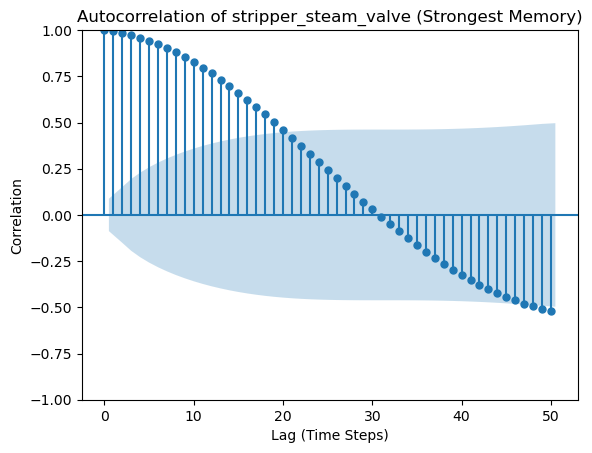

In [34]:
normal_episode_data = train_data[(train_data['faultNumber'] == 0) & (train_data['simulationRun'] == 1)]

memory_scores = {}
# Calculate ACF for 20 lags for all sensors
for sensor in sensor_cols:
    sensor_array = normal_episode_data[sensor].values
    autocorr_values = acf(sensor_array, nlags=20, fft=True)
    memory_scores[sensor] = sum(abs(autocorr_values[1:])) 

highest_memory_sensor = max(memory_scores, key=memory_scores.get)
print(f"The sensor with the strongest temporal memory is {highest_memory_sensor}")

plt.figure(figsize=(10, 4))
plot_acf(normal_episode_data[highest_memory_sensor], lags=50, alpha=0.05)
plt.title(f'Autocorrelation of {highest_memory_sensor} (Strongest Memory)')
plt.xlabel('Lag (Time Steps)')
plt.ylabel('Correlation')
plt.show()